In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

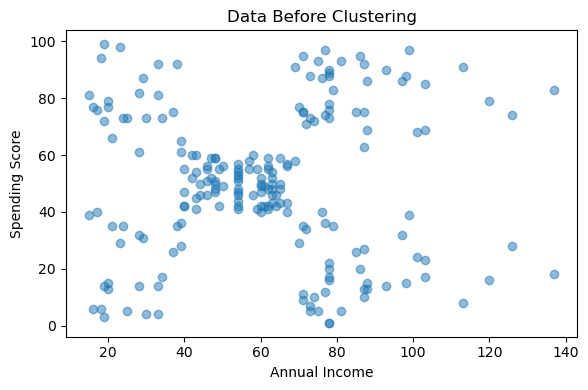

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], alpha = 0.5)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Data Before Clustering")
plt.tight_layout()

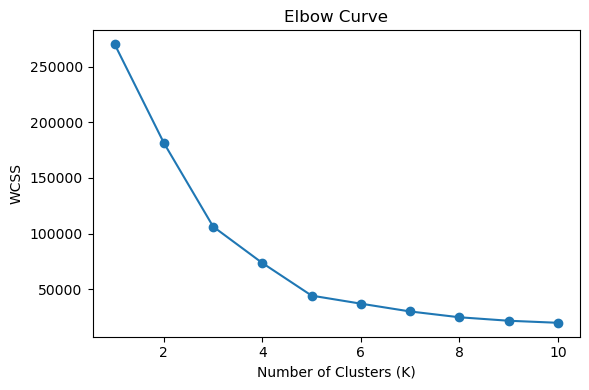

In [5]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)   # WCSS
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.tight_layout()

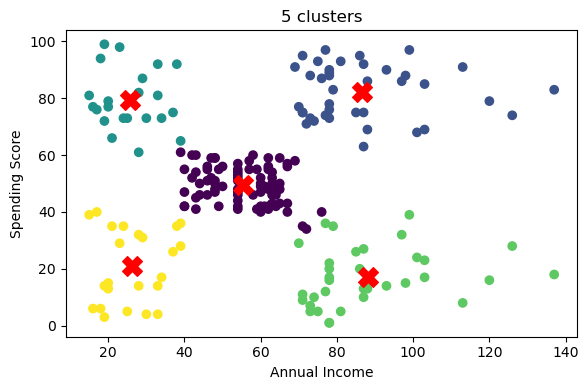

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
plt.figure(figsize=(6,4))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            marker='X', s=200, color = "red")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("5 clusters")
plt.tight_layout()

The clustering with K = 5 shows well-separated and compact clusters. 
Each cluster represents a distinct customer segment with clear differences 
in income and spending behavior. The centroids are positioned at the center 
of dense regions, indicating stable clustering.

This configuration provides a good balance between simplicity and meaningful segmentation.

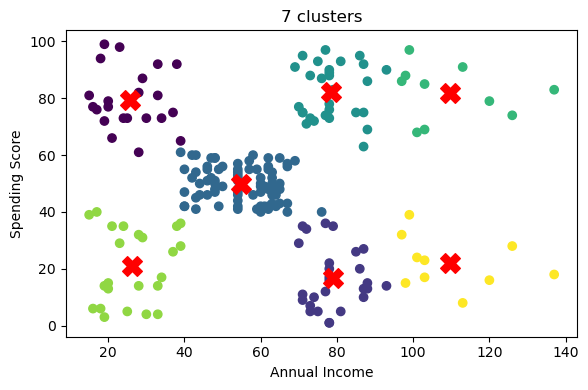

In [7]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
plt.figure(figsize=(6,4))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            marker='X', s=200, color = "red")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("7 clusters")
plt.tight_layout()

The clustering with K = 7 results in over-segmentation. 
Some natural clusters are unnecessarily split into smaller groups, 
leading to overlapping and less interpretable clusters.

This indicates that increasing K beyond the optimal value does not 
improve clustering quality and instead reduces clarity.

# 🔹 Conclusion
In this analysis, K-Means clustering was applied on the Mall Customers dataset using 
'Annual Income' and 'Spending Score' as features.

Initially, the data was visualized to understand its distribution, which showed potential 
groupings but no clear boundaries.

To determine the optimal number of clusters, the Elbow Method was used. The curve showed 
a noticeable bend around K = 5, indicating diminishing returns beyond this point.

Clustering results for K = 5 showed well-defined and meaningful groups, while higher 
values like K = 7 resulted in over-segmentation, splitting natural clusters unnecessarily.

Therefore, K = 5 was selected as the optimal number of clusters.

This clustering helps in identifying different customer segments such as:
- High income – high spending (premium customers)
- High income – low spending (potential targets)
- Low income – high spending (impulsive buyers)
- Low income – low spending (low-value customers)
- Average customers

Overall, K-Means effectively grouped customers into meaningful segments that can be used 
for targeted marketing and business decision-making.